# Lesson 06a: The Equivariant Point Convolution (Tensor Field Networks)

**What you will learn**

- The **Tensor Field Networks (TFNs) point convolution**: The messages,
  expressed as $m_{ij} = \bigl(R(|\vec r_{ij}|)\, Y(\hat r_{ij})\bigr) \otimes_w
  h_j$, followed by the summation over neighbors and the self-interaction.
- A complete **proof of equivariance**, factor by factor.
- A step-by-step **e3nn implementation** of a TFN: spherical harmonics of edge
  vectors $\to$ tensor product with per-edge weights $\to$ radial MLP $\to$
  scatter-sum aggregation $\to$ `o3.Linear` self-interaction.
- A numerical **equivariance verification** of the assembled TFN under random
  E(3) transformations.
- How the **receptive field** grows with message-passing depth.

**Prerequisites:** 

- Lesson 02b: Spherical harmonics,
- Lesson 03a/03b: Tensor products (`FullyConnectedTensorProduct`),
- Lesson 04: Gates,
- Lesson 05a: Radius graphs, and the edge vector convention, $\vec r_{ij} = \vec r_j - \vec r_i$,
- Lesson 05b: Bessel basis, and polynomial cutoff.

In [1]:
import sys
sys.path.insert(0, "..")

import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from ase.build import molecule
from e3nn import o3, nn as enn

from course_utils.data import radius_graph
from course_utils.equivariance import assert_model_equivariant

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)  # we will *verify* equivariance: float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## From invariant to equivariant messages

In Lesson 05a, we mentioned how node $i$ receives messages, $m_{ij}$, from its
neighbors $j$ and aggregates them with a sum. *Invariant* networks such as
SchNet ([Lesson 07a](07a_schnet.ipynb)) often build messages, $m_{ij}$, from
distances, $d_{ij} = |\vec r_{ij}|$, alone and throw away the *directions*,
$\hat r_{ij}$. In order to use directions without breaking the symmetry, the
message must **transform correctly** under rotations. As such, the message must
be built from equivariant ingredients only.

Tensor Field Networks (TFNs) address this issue by restricting the convolution
filter to the product of a **learned radial function** and a **spherical
harmonic**:

$$
F^{(l_f, l_i)}_{cm}(\vec r) \;=\; R^{(l_f, l_i)}_c(r)\, Y^{(l_f)}_m(\hat r)
$$

where, $c$ denotes the channel index, $l_i$ and $l_f$ are non-negative integers
corresponding to the rotation order of the input and the filter, respectively,
and $R^{(l_f,l_i)}_c : \mathbb{R}_{0^+} \to \mathbb{R}$ are functions that are
learned during training and contain most of the parameters in the TFN. The
filter inherits the transformation properties of $Y^{(l_f)}(\hat r)$ because
$R(r)$ itself is rotation-invariant.

Once filters and node features are created, they are combined using the
**Clebsch–Gordan coefficients** (Lesson 03a), yielding the point convolution:

$$ \mathcal{L}^{(l_o)}_{acm_o}\!\left(\vec r_a, V^{(l_i)}_{acm_i}\right) \;=\;
\sum_{m_f, m_i} C^{(l_o, m_o)}_{(l_f, m_f)(l_i, m_i)} \sum_{b \in S}
F^{(l_f, l_i)}_{cm_f}(\vec r_{ab})\, V^{(l_i)}_{bcm_i} $$

where $a$ is the point being updated, $b$ runs over **all** other points of the
cloud $S$, and $V^{(l_i)}_{bcm_i}$ are the input features. 

> **Note:** The original implementation of TFN defines the convolution as a
*global* operation: it has no cutoff, and the [reference
code](https://github.com/tensorfieldnetworks/tensorfieldnetworks) contracts a
full $N \times N$ difference matrix. Following Lesson 05a, we will instead sum
only over the radius-graph neighborhood $\mathcal{N}(i) \subset S$. Furthermore,
TFN defines $\vec r_{ab} := \vec r_a - \vec r_b$: pointing from sender $b$ *to*
receiver $a$. Our course convention (STYLE_GUIDE, Lesson 05a) is the opposite:
$\vec r_{ij} = \vec r_j - \vec r_i$ points from receiver $i$ *toward* sender
$j$, so $\vec r_{ab} = -\vec r_{ij}$ for $(a,b)=(i,j)$. Since $Y^{(l)}(-\hat r)
= (-1)^l\, Y^{(l)}(\hat r)$, the two conventions differ only by a fixed sign per
$l$, which the learned $R$ absorbs. We use the course convention throughout.

In the compact message-passing notation used for the rest of this course, one
TFN layer updating $h_i^{(t)} \to h_i^{(t+1)}$ reads

$$
\begin{gather}
m_{ij} \;=\; \Bigl( R\bigl(|\vec r_{ij}|\bigr)\, Y\bigl(\hat r_{ij}\bigr) \Bigr) \otimes_w h_j, \\
h_i^{(t+1)} \;=\; \mathrm{Linear}\Bigl( \sum_{j \in \mathcal{N}(i)} m_{ij} \Bigr)
\end{gather}
$$

where $\otimes_w$ is the weighted tensor product of [Lesson
03b](03b_tensor_products_e3nn.ipynb) whose path weights $w = R(|\vec r_{ij}|)$
are **produced per edge** by the radial network, and $\mathrm{Linear}()$ is
TFN's self-interaction. Compared to the original TFN which does not add weights
in the tensor product and perform a linear operation after it, we use the fully
connected `'uvw'` form (`o3.FullyConnectedTensorProduct`) which corresponds to
the same function class but incorporates the weights inside the product.

## Bonus section: Proof of equivariance

<details><summary>Open to read</summary>

Let the input positions transform by an arbitrary element of E(3): $\vec r_a
\mapsto g\,\vec r_a + \vec t$ with $g \in O(3)$ (rotation, possibly composed
with the inversion) and $\vec t \in \mathbb{R}^3$. We show each factor of
$m_{ij}$ transforms as an irrep, so their combination does too. Node features
carry irreps (as `irreps_in`) with a corresponding representation matrix,
$D_\mathrm{in}(g)$, and we use $D^{(l,p)}$ to represent an irrep $(l, p)$.

In order to prove the equivariance of our TFN, it is sufficient to prove the
equivariance of every layer in it. This is because the composition of
equivariant functions is also equivariant. Let us go through all network
operations and check their equivariance:

**(i) Relative vectors are translation invariant.** From Lesson 05a, the
relative vectors absorb the rotation while the translation terms $\vec t$
cancel:

$$
\vec r_{ij} \;\mapsto\; (g\,\vec r_j + \vec t) - (g\,\vec r_i + \vec t)
\;=\; g\,\vec r_{ij}.
$$

Because $g$ is orthogonal, the lengths are also preserved, $d_{ij} = |g\,\vec
r_{ij}| = |\vec r_{ij}|$, and with them the edge set $\mathcal{E}$: both are
invariant under the full E(3) action.

**(ii) The radial factor is invariant.** $R$ (our radial MLP) sees only
$d_{ij}$, which is invariant by (i), so $R(d_{ij}) \mapsto R(d_{ij})$. Scalars
(in $m$) commute with everything.

**(iii) Spherical harmonics are equivariant.** From Lesson 02b, for a given
rotation $g \in SO(3)$, the spherical harmonics transform as

$$ 
Y^{(l)}_m\bigl(R(g)\,\hat r\bigr) = \sum_{m'} D^{(l)}_{mm'}(g)\,
Y^{(l)}_{m'}(\hat r), 
$$ 

and under the inversion 

$$ Y^{(l)}(-\hat r) = (-1)^l\, Y^{(l)}(\hat r). $$

Thus, $Y^{(l)}$ transforms as the irrep $(l,\, p = (-1)^l)$: `0e`, `1o`, `2e`, …
Altogether $Y(\hat r_{ij}) \mapsto D_{\mathrm{sh}}(g)\, Y(\hat r_{ij})$.

**(iv) Node features transform equivariantly — induction on the layer index.**
*Claim:* at every layer $t$ there is a (block-diagonal) representation matrix
$D^{(t)}(g)$, built from the layer's irreps, such that

$$ h_j^{(t)} \;\mapsto\; D^{(t)}(g)\, h_j^{(t)} \qquad \text{for every node } j. $$

*Base case* ($t = 0$): a rigid motion moves atoms but does not change their
chemical species, so the one-hot input $h_j^{(0)}$ remains unchanged. One-hot
representations are vectors of `0e` scalars, whose representation matrix is
$D^{(0)}(g) = \mathbb{1}$ for **every** $g \in O(3)$, including rotations and
inversion. Hence $h_j^{(0)} \mapsto D^{(0)}(g)\, h_j^{(0)} = h_j^{(0)}$, and the
base case holds.

*Inductive step:* assume the claim at layer $t$ and abbreviate $D_\mathrm{in} :=
D^{(t)}$, $D_\mathrm{out} := D^{(t+1)}$. Steps (v)–(vii) below show that every
operation the layer applies, including the weighted tensor product, the neighbor
sum, and the self-interaction, carries $D_\mathrm{in}$-features to
$D_\mathrm{out}$-features. Under this hypothesis, one layer computes
$h_i^{(t+1)} = \mathrm{Linear}\bigl(\sum_{j \in \mathcal{N}(i)} m_{ij}\bigr)$,
and each move transforms as required: the per-edge weights $R(d_{ij})$ are
unchanged by (i)–(ii); $Y \mapsto D_\mathrm{sh}\, Y$ by (iii); the weighted
tensor product therefore sends $m_{ij} \mapsto D_\mathrm{out}(g)\, m_{ij}$ by
(v); and the neighbor sum and the self-interaction commute with
$D_\mathrm{out}(g)$ by (vi)–(vii). Hence

$$ h_i^{(t+1)} \;\mapsto\; D^{(t+1)}(g)\, h_i^{(t+1)}, $$

which is the claim of (iv) one layer up. By induction over the $T$ layers: 

$$
h^{(T)}\bigl(\{g \vec r + \vec t\,\}\bigr) \;=\; D_\mathrm{out}(g)\;
h^{(T)}\bigl(\{\vec r\,\}\bigr) \qquad \forall\, g \in O(3),\ \vec t \in
\mathbb{R}^3.
$$

**(v) The tensor product intertwines.** The Clebsch–Gordan coefficients satisfy
the invariance property of Lesson 03a, 

$$ 
\sum_{m_1' m_2'} C^{(l_3, m_3)}_{(l_1,
m_1')(l_2, m_2')}\, D^{(l_1)}_{m_1' m_1}(g)\, D^{(l_2)}_{m_2' m_2}(g) =
\sum_{m_3'} D^{(l_3)}_{m_3 m_3'}(g)\, C^{(l_3, m_3')}_{(l_1, m_1)(l_2, m_2)},
$$

and parities multiply: $p_3 = p_1 p_2$. Hence, for each output irrep of the
weighted tensor product: 

$$
m_{ij} \;\mapsto\; R(d_{ij})\,\Bigl(D_\mathrm{sh}\,Y
\Bigr) \otimes \Bigl(D_\mathrm{in}\, h_j\Bigr) \;=\; D_\mathrm{out}(g)\;
\underbrace{\Bigl(R(d_{ij})\, Y \otimes h_j\Bigr)}_{m_{ij}}.
$$

**(vi) The sum over neighbors commutes.** By (i) the neighbor set
$\mathcal{N}(i)$ is unchanged, and $D_\mathrm{out}(g)$ is linear: $\;\sum_j
D_\mathrm{out} m_{ij} = D_\mathrm{out} \sum_j m_{ij}$. Note that any *linear*
permutation-invariant aggregation operation works here. However, operations such
as a componentwise max would not (See Exercise 3 for an example).

**(vii) Self-interaction commutes.** `o3.Linear` mixes channels within each
irrep with weights shared across $m$. In other words, the same weights are used
for every $m$ for a given order $l$ which is essential to maintain equivariance.
A block-diagonal $D$ implies $W D = D W$.

</details>

## Step-by-step implementation of a TFN

Let us build a TFN layer step by step, and verify its equivariance numerically.

We work on the ethanol radius graph from Lesson 05a, with one-hot species as the
initial `0e` node features $h_j^{(0)}$.

In [2]:
# Create the ethanol molecule using ASE
atoms = molecule("CH3CH2OH")

# Get the positions of the atoms (N, 3)
pos = torch.tensor(atoms.get_positions())

# Set the cutoff radius
r_cut = 2.5

# Compute the radius graph: edges are pairs of atoms within r_cut distance
# (2, E): [receiver i, sender j]
edge_index = radius_graph(pos, r_cut)
i, j = edge_index

# r_ij = r_j - r_i  (course convention)
edge_vec = pos[j] - pos[i]
edge_len = edge_vec.norm(dim=-1)

# Get the chemical symbols: ['C', 'H', 'O']
species = sorted(set(atoms.get_chemical_symbols()))

# Create a tensor to hold the one-hot features for each atom (N, len(species))
node_attr = torch.zeros(len(pos), len(species))

# Fill the one-hot features for each atom based on its chemical species
for a, s in enumerate(atoms.get_chemical_symbols()):
    node_attr[a, species.index(s)] = 1.0
    
# Create the input irreps for the one-hot features: len(species) copies of 0e
# one-hot species = invariant scalars
irreps_in = o3.Irreps(f"{len(species)}x0e")

# Compute the average number of neighbors per atom
avg_neighbors = edge_index.shape[1] / len(pos)
print(f"N = {len(pos)}, E = {edge_index.shape[1]}, <deg> = {avg_neighbors:.1f}, h^0 irreps: {irreps_in}")

N = 9, E = 54, <deg> = 6.0, h^0 irreps: 3x0e


We have created the one-hot representation of the chemical species for each atom
in the ethanol molecule. The one-hot features are stored in `node_attr`, and the
input irreps for these features are defined as `irreps_in`, which consists of
`len(species)` copies of the `0e` irrep, representing invariant scalars.

Let us now proceed to the next step of the implementation, which involves
computing the spherical harmonics of the edge directions $Y(\hat r_{ij})$.

### Step 1: Spherical harmonics of the edge directions $Y(\hat r_{ij})$

The edge featyres are the $Y^{(l_f)}_m(\hat r)$ factor in TFN. We use
`normalize=True` which divides each edge vector by its length first: The
spherical harmonics see **only the direction**, which is exactly the
radial/angular factorization of the TFN filter layer. Setting $l_\mathrm{max} =
2$, the filter irreps become `1x0e + 1x1o + 2e`. Note the parities $(-1)^l$ of
the irreps, which are important for the equivariance.

In [3]:
# Set the maximum degree of spherical harmonics to compute
l_max = 2

# 1x0e + 1x1o + 1x2e
irreps_sh = o3.Irreps.spherical_harmonics(l_max)

# Compute the spherical harmonics of the edge directions
Y = o3.spherical_harmonics(irreps_sh, edge_vec, normalize=True, normalization="component")
print(f"irreps_sh = {irreps_sh},   Y: {tuple(Y.shape)}  (E edges x {irreps_sh.dim})")

irreps_sh = 1x0e+1x1o+1x2e,   Y: (54, 9)  (E edges x 9)


### Step 2: The weighted tensor product $\;Y \otimes_w h_j$

We implement the Clebsch–Gordan contraction of TFN as `o3.FullyConnectedTensorProduct` (Lesson 03b). 

There are wwo crucial constructor flags:

- `shared_weights=False`: Every **edge** gets its own path weights (the weights
  *are* the radial functions evaluated at that edge's length);
- `internal_weights=False`: The module owns **no** weight tensor. So, we will
  pass `weight=` at call time.

The module enumerates every symmetry-allowed path $(l_i, p_i) \otimes (l_f, p_f)
\to (l_o, p_o)$ and tells us how many scalar weights per edge it expects
(`weight_numel`).

In [4]:
# Create irreps for the features of the updated node
irreps_out = o3.Irreps("8x0e + 8x1o + 8x2e")

# Initialize a FullyConnectedTensorProduct object
tp = o3.FullyConnectedTensorProduct(
    irreps_in, irreps_sh, irreps_out,
    shared_weights=False,    # one weight set per edge ...
    internal_weights=False,  # ... supplied externally: weight = R(d_ij)
)
print(tp)
print(f"\npath weights per edge: tp.weight_numel = {tp.weight_numel}")

FullyConnectedTensorProduct(3x0e x 1x0e+1x1o+1x2e -> 8x0e+8x1o+8x2e | 72 paths | 72 weights)

path weights per edge: tp.weight_numel = 72


### Step 3: the radial network $R(d_{ij})$ produces the weights

TFN's learned radial functions, $R^{(l_f,l_i)}_c(r)$, map the **Bessel radial
basis** of the edge lengths (Lesson 05b) to the `weight_numel` path weights. We
use `e3nn.nn.FullyConnectedNet` (a plain scalar MLP: it may be arbitrarily
nonlinear because scalars carry the trivial representation)

We also multiply the basis *and* the finished messages by the polynomial
envelope $u(d)$ of Lesson 05b, so every message smoothly decays to zero at
$r_\mathrm{cut}$.

In [5]:
# Create DimeNet's RBFs
class BesselBasis(torch.nn.Module):
    """DimeNet radial Bessel basis: built and discussed in Lesson 05b."""

    def __init__(self, r_cut: float, n_basis: int = 8):
        super().__init__()
        self.prefactor = math.sqrt(2.0 / r_cut)
        self.register_buffer("k_n", torch.arange(1, n_basis + 1) * math.pi / r_cut)

    def forward(self, d):
        d = d.unsqueeze(-1)
        return self.prefactor * torch.sin(self.k_n * d) / d

# Create DimeNet's envelope
class PolynomialCutoff(torch.nn.Module):
    """DimeNet envelope u(d) with d -> d/r_cut: see Lesson 05b."""

    def __init__(self, r_cut: float, p: int = 6):
        super().__init__()
        self.r_cut, self.p = r_cut, p

    def forward(self, d):
        x, p = d / self.r_cut, self.p
        u = (1.0 - (p + 1) * (p + 2) / 2 * x**p + p * (p + 2) * x**(p + 1)
             - p * (p + 1) / 2 * x**(p + 2))
        return torch.where(d < self.r_cut, u, torch.zeros_like(d))

# Use 8 basis functions
n_basis = 8

# Generate the basis functions and polynomial envelop
basis, envelope = BesselBasis(r_cut, n_basis), PolynomialCutoff(r_cut)

# Create an MLP for 
radial_mlp = enn.FullyConnectedNet([n_basis, 16, tp.weight_numel], torch.nn.functional.silu)

# (E,)
u = envelope(edge_len)

# (E, weight_numel) = R(d_ij)
w = radial_mlp(basis(edge_len) * u.unsqueeze(-1))
print(f"radial weights w: {tuple(w.shape)}   (one row of path weights per edge)")

radial weights w: (54, 72)   (one row of path weights per edge)


### Step 4: Messages and scatter-sum aggregation

Here, we focus on building the messages and their aggregation, respectively.
That is, $m_{ij} = \bigl(R(d_{ij})\, Y(\hat r_{ij})\bigr) \otimes_w h_j$, and
$\sum_{j \in \mathcal N(i)} m_{ij}$. Recall the indexing discipline from Lesson
05a: the tensor product consumes **sender** features `h[j]`, and `index_add_`
scatters each message onto its **receiver** row `i`. This yields the $\sum_{b
\in S}$ in the aggregation which is restricted to the radius-graph neighborhood
$\mathcal{N}(i)$. We divide the result by $\sqrt{\langle\deg\rangle}$ so feature
magnitudes stay $O(1)$ regardless of coordination (we will meet this
normalization again in the NequIP implementation in [Lesson
08b](08b_nequip_implementation.ipynb)).

In [6]:
# h^(0): (N, irreps_in.dim)
h = node_attr

# Create the messages
# (E, irreps_out.dim) with u smooth at r_cut
messages = tp(h[j], Y, weight=w) * u.unsqueeze(-1)

# Create a container for aggregation
# (N, irreps_out.dim)
agg = torch.zeros(len(pos), irreps_out.dim)

# sum_{j in N(i)} m_ij   [scatter-sum]
agg.index_add_(0, i, messages)

# Average by sqrt(<deg>)
agg = agg / avg_neighbors**0.5

print(f"messages: {tuple(messages.shape)}  ->  aggregated node features: {tuple(agg.shape)}")

messages: (54, 72)  ->  aggregated node features: (9, 72)


### Step 5: Self-interaction

Following SchNet, a *self-interaction* layer mixes the channels **within each
irrep** at every node which is *"analogous to 1x1 convolutions"*. The weights
are shared across $m$ which, in e3nn, exactly translates to `o3.Linear`.

In [7]:
# Create a self-interaction linear layer
self_interaction = o3.Linear(irreps_out, irreps_out)

# Apply the self-interaction layer to create h^(1)
h1 = self_interaction(agg)
print(f"h^(1): {tuple(h1.shape)} carrying irreps {irreps_out}")

h^(1): (9, 72) carrying irreps 8x0e+8x1o+8x2e


### Final assembly: One reusable convolution module

Here, we bring steps 1-5 together in a single reusable TFN convolution
`nn.Module`

In [8]:
class TFNConv(torch.nn.Module):
    def __init__(self, irreps_in, irreps_out, r_cut, l_max=2, n_basis=8, avg_neighbors=1.0):
        super().__init__()
        self.irreps_sh = o3.Irreps.spherical_harmonics(l_max)
        self.tp = o3.FullyConnectedTensorProduct(
            irreps_in, self.irreps_sh, irreps_out,
            shared_weights=False, internal_weights=False)
        self.basis, self.envelope = BesselBasis(r_cut, n_basis), PolynomialCutoff(r_cut)
        self.radial_mlp = enn.FullyConnectedNet(
            [n_basis, 16, self.tp.weight_numel], torch.nn.functional.silu)
        self.self_interaction = o3.Linear(irreps_out, irreps_out)
        self.norm = avg_neighbors ** 0.5

    def forward(self, h, edge_index, edge_vec):
        i, j = edge_index
        d = edge_vec.norm(dim=-1)
        Y = o3.spherical_harmonics(self.irreps_sh, edge_vec,
                                   normalize=True, normalization="component")  # step 1
        u = self.envelope(d)
        w = self.radial_mlp(self.basis(d) * u.unsqueeze(-1))                   # step 3
        m = self.tp(h[j], Y, weight=w) * u.unsqueeze(-1)                       # steps 2+4
        agg = torch.zeros(h.shape[0], m.shape[1], dtype=h.dtype, device=h.device)
        agg.index_add_(0, i, m)                                                # step 4
        return self.self_interaction(agg / self.norm)                          # step 5

### A two-layer equivariant GNN

Stacking convolutions needs an equivariant nonlinearity between them: the `Gate`
of Lesson 04. The model maps **positions** (plus fixed species and graph) to
per-node equivariant features:

In [9]:
class EquivariantGNN(torch.nn.Module):
    def __init__(self, irreps_in, irreps_out, r_cut, avg_neighbors=1.0):
        super().__init__()
        self.gate = enn.Gate("8x0e", [torch.nn.functional.silu],   # scalars, activated
                             "16x0e", [torch.sigmoid],             # gate scalars ...
                             "8x1o + 8x2e")                        # ... gating these
        self.conv1 = TFNConv(irreps_in, self.gate.irreps_in, r_cut, avg_neighbors=avg_neighbors)
        self.conv2 = TFNConv(self.gate.irreps_out, irreps_out, r_cut, avg_neighbors=avg_neighbors)

    def forward(self, pos, node_attr, edge_index):
        # r_ij = r_j - r_i
        edge_vec = pos[edge_index[1]] - pos[edge_index[0]]
        h = self.gate(self.conv1(node_attr, edge_index, edge_vec))
        return self.conv2(h, edge_index, edge_vec)

# Output irreps
irreps_out = o3.Irreps("4x0e + 4x1o + 4x2e")

# Crete the equivariant GNN
model = EquivariantGNN(irreps_in, irreps_out, r_cut, avg_neighbors)

# Print the input/output irreps to/from Gate
print(model.gate.irreps_in, "-> gate ->", model.gate.irreps_out)

# Print the number of parameters
print(f"parameters: {sum(p.numel() for p in model.parameters())}")

# Print the GNN output node features 
h_out = model(pos, node_attr, edge_index)
print(f"output node features: {tuple(h_out.shape)} = (N, {irreps_out.dim})")

24x0e+8x1o+8x2e -> gate -> 8x0e+8x1o+8x2e
parameters: 8560
output node features: (9, 36) = (N, 36)


## Verify equivariance

The `assert_model_equivariant` harness can wrap the `EquivariantGNN` instance
and draw random $g \in O(3)$ (rotations, half the time composed with the
inversion) and random translations $\vec t$ to check its equivariance to
`float64` precision, where

$$
\mathrm{model}(g\,\mathrm{pos} + \vec t) \;\overset{?}{=}\; D_\mathrm{out}(g)\; \mathrm{model}(\mathrm{pos})
$$

The species' one-hot and `edge_index` features are passed through the network
unchanged because `0e` scalars do not transform and the edge set remains
E(3)-invariant. Any bug in the proof chain such as a wrong parity, weights that
depend on direction, a nonlinearity applied to $l>0$ components should show up
here.

In [10]:
assert_model_equivariant(
    model, pos, irreps_out,
    node_attr=node_attr, edge_index=edge_index,
)

equivariant!  (max error 2.446e-16 over random O(3) + translations elements)


2.445960101127298e-16

## Receptive field: How far can a node see?

One convolution layer only couples atoms within $r_\mathrm{cut}$. Stacking $T$
layers lets information hop $T$ times: node $i$'s features depend on all atoms
within **graph distance $T$**, i.e. a ball of radius $\approx T \cdot
r_\mathrm{cut}$. That is how message-passing models capture interactions beyond
the cutoff *without* enlarging the (expensive, $\propto r_\mathrm{cut}^3$)
neighbor lists. Unfortunately, this can also become their scaling weakness:
layers run sequentially, and the growing receptive field entangles far-apart
atoms. Allegro's strictly-local alternative, discussed in [Lesson
09](09a_allegro_theory.ipynb) is motivated exactly by this issue.

We can *measure* the receptive field with autograd: put $T$ convolutions on a
24-atom chain (spacing $1.0$, $r_\mathrm{cut} = 1.2$ $\to$ nearest-neighbor
graph) and compute the sensitivity $\lVert \partial h_{12} / \partial \vec r_k
\rVert$ of the central node's output to every atom $k$. Let's see this in action
alongside an illustrative example:

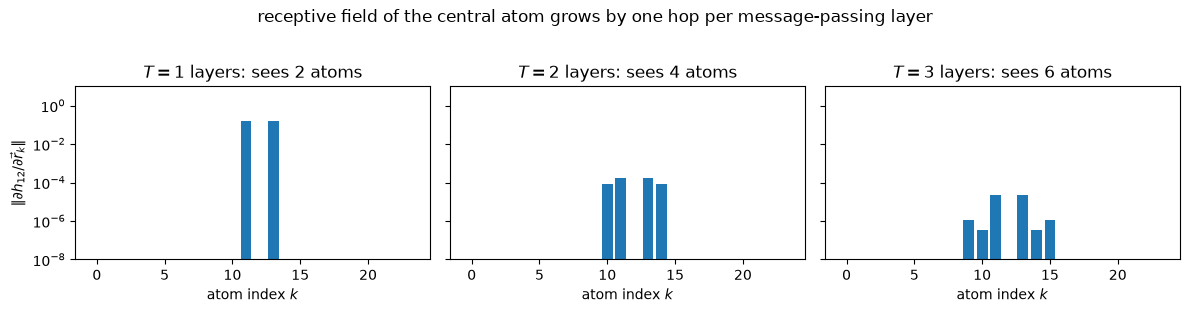

In [11]:
# Create a 24 atom chain, 1.0 apart from each other
chain = torch.stack([torch.arange(24.0), torch.zeros(24), torch.zeros(24)], dim=-1)

# Create a radius graph for the chain
ei_chain = radius_graph(chain, 1.2)

# Center of the chain
center = 12

# Stacked TFN convolutions
class ConvStack(torch.nn.Module):
    def __init__(self, T):
        super().__init__()
        irreps = ["1x0e"] + ["4x0e + 4x1o"] * (T - 1) + ["1x0e"]
        self.convs = torch.nn.ModuleList(
            [TFNConv(irreps[t], irreps[t + 1], r_cut=1.2, l_max=1, avg_neighbors=2.0)
             for t in range(T)])

    def forward(self, pos, edge_index):
        h = torch.ones(pos.shape[0], 1, dtype=pos.dtype)
        edge_vec = pos[edge_index[1]] - pos[edge_index[0]]
        for conv in self.convs:
            h = conv(h, edge_index, edge_vec)
        return h

# Create a plot of sensitivity vs. atom index
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, T in zip(axes, (1, 2, 3)):
    torch.manual_seed(0)
    # Get a copy of the chain
    p = chain.clone().requires_grad_(True)
    
    # Create an instance of the model with T convolution layers
    out = ConvStack(T)(p, ei_chain)[center].sum()
    
    # Calculate the gradient of the output w.r.t positions
    (g,) = torch.autograd.grad(out, p)
    
    # Calculate the sensitivity
    sens = g.norm(dim=-1)
    
    # Edit the subplots
    ax.bar(range(24), sens.clamp_min(1e-20), color=["tab:red" if k == center else "C0" for k in range(24)])
    ax.set_yscale("log")
    ax.set_ylim(1e-8, 1e1)
    ax.set_title(f"$T = {T}$ layers: sees {int((sens > 1e-12).sum())} atoms")
    ax.set_xlabel("atom index $k$")

axes[0].set_ylabel(r"$\Vert \partial h_{12} / \partial \vec r_k \Vert$")
fig.suptitle("receptive field of the central atom grows by one hop per message-passing layer", y=1.03)
fig.tight_layout()
plt.show()

These plots show that the receptive field with respect to the centeral atom
increases exactly one extra hop per layer and becomes zero outside the field. As
such, locality is an architectural feature and a not learned one.

## Summary

In this lesson, we have learned:

- The TFN point convolution restricts filters to $F(\vec r) = R(r)\, Y(\hat r)$
  and couples them to node features, $h_j$ with Clebsch–Gordan coefficients. In
  message-passing framework, it can be expressed as: $m_{ij} = (R(|\vec
  r_{ij}|)\, Y(\hat r_{ij})) \otimes_w h_j$, aggregation (sum over $j$), then
  `o3.Linear` self-interaction.
- Equivariance follows from the network construction, factor by factor.
- The e3nn recipe involves: `o3.spherical_harmonics`,
  `o3.FullyConnectedTensorProduct(shared_weights=False,
  internal_weights=False)`, `FullyConnectedNet` radial MLP on (enveloped) Bessel
  features, `index_add_` scatter-sum and `o3.Linear`. We have verified our
  model's equivariance, numerically up to $10^{-15}$.
- For a stack of $T$ convolution layers, the receptive field is of $T$ hops
  ($\approx T \cdot r_\mathrm{cut}$).

**Next:** In [Lesson 06b](06b_tetris_end_to_end.ipynb) we will apply the
convolution layers to train an equivariant model end-to-end and use it for
classifying a set of chiral shapes in the tetris dataset.

## Exercises

**1. The `'uvu'` vs `'uvw'` modes.** Rebuild `tp` as the original TFN
factorization: an `o3.TensorProduct` with `'uvu'` instructions (no cross-channel
mixing inside the product) followed by the `o3.Linear`. Compare `weight_numel`
and total parameters with the `'uvw'` version.

<details><summary>Solution</summary>

```python
# Rebuild the tensor product with 'uvu' instructions
# uvu: out follows in1
instructions = [(i1, i2, i_out, "uvu", True)
                for i1, (_, ir1) in enumerate(tp.irreps_in1)
                for i2, (_, ir2) in enumerate(tp.irreps_in2)
                for i_out, (_, ir_out) in enumerate(tp.irreps_in1)
                if ir_out in ir1 * ir2]
```

For our first layer this is awkward because `irreps_in1 = 3x0e` has no $l>0$
slots which is *why* TFN/NequIP-style `uvu` layers choose `irreps_out` to mirror
the input multiplicities and add a Linear afterwards. The headline: `uvu` weight
count grows like (paths × multiplicity), `uvw` like (paths × mul_in × mul_out).
As such, `uvw` is more expressive per layer and `uvu` is much cheaper. Both
NequIP and MACE choose `uvu` + Linear in their architecture to balance the model
expressiveness with the computational cost. 
</details>

**2. Smooth messages.** Plot $\lVert m_{ij}\rVert$ against $d_{ij}$ for one
trained-at-random `TFNConv` by scanning a two-atom system's separation through
$r_\mathrm{cut}$. Confirm messages vanish smoothly (Lesson 05b) and explain
which two factors in `forward` guarantee it.

<details><summary>Solution</summary>

**Setup.** Two atoms and a *single* fixed edge $j = 1 \to i = 0$ are sufficient.
Here, we slide the sender along the $x$-axis and record the message it emits.
Two deliberate choices make the experiment informative:

- We keep the edge alive even for $d > r_\mathrm{cut}$. In a real `radius_graph`
  the edge would be *deleted* but we want to see what value the message would
  jump from if it did not already vanish at the cutoff.
- We replay `forward` from `conv`'s own submodules (same weights) instead of
  calling `conv(...)`, so that we can toggle the two envelope factors
  independently and even swap the radial network.

```python
# Random seed for reproducibility
torch.manual_seed(0)

# Initialize the model (trained-at-random)
conv = TFNConv("1x0e", "4x0e+4x1o", r_cut=2.5)

# A plain torch MLP of the same shape -- its Linear layers have biases,
# like the two dense layers of the original TFN radial network R(r)
biased_mlp = torch.nn.Sequential(torch.nn.Linear(8, 16), torch.nn.SiLU(),
                                 torch.nn.Linear(16, conv.tp.weight_numel))

# One 0e feature per atom
h = torch.ones(2, 1)

# Single edge: receiver 0 <- sender 1
ei = torch.tensor([[0], [1]])

# A grid of 400 points for the edge scan
ds = torch.linspace(0.5, 3.0, 400)

# Create the message norm
def message_norm(d, radial=None, envelope_message=True):
    """||m_01|| at separation d, replaying TFNConv.forward step by step."""
    radial = radial or conv.radial_mlp
    # Calculate the edge vector
    edge_vec = torch.tensor([[d, 0.0, 0.0]])
    dd = edge_vec.norm(dim=-1)
    # Calculate the spherical harmonics
    Y = o3.spherical_harmonics(conv.irreps_sh, edge_vec,
                               normalize=True, normalization="component")
    # Compute the envelop on the grid
    u = conv.envelope(dd)
    # Factor 1: enveloped basis
    w = radial(conv.basis(dd) * u.unsqueeze(-1))
    m = conv.tp(h[ei[1]], Y, weight=w)
    if envelope_message:
        # Factor 2: enveloped message
        m = m * u.unsqueeze(-1)
    return m.norm().item()

# Bookkeeping for ablation
with torch.no_grad():
    curves = {
        "TFNConv (both factors)":            [message_norm(d) for d in ds],
        "no factor 2 (e3nn radial MLP)":     [message_norm(d, envelope_message=False) for d in ds],
        "no factor 2, biased radial MLP":    [message_norm(d, radial=biased_mlp,
                                                           envelope_message=False) for d in ds],
        "factor 2 back, biased radial MLP":  [message_norm(d, radial=biased_mlp) for d in ds],
    }

# Generate the plot
for (label, ns), style in zip(curves.items(), ["-", ":", "--", "-."]):
    plt.plot(ds, ns, style, label=label)
plt.axvline(2.5, color="gray", lw=0.8)
plt.xlabel("$d_{ij}$")
plt.ylabel(r"$\Vert m_{ij} \Vert$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
```

The plot shows that the real `TFNConv` curve bends down and reaches *exactly
zero at* $d = r_\mathrm{cut}$. It also becomes flat: the envelope satisfies $u =
u' = u'' = 0$ at the cutoff (Lesson 05b) and stays zero beyond. 

The two ablations then separate the roles of the two factors in `forward`:

1. `w = radial_mlp(basis(d) * u.unsqueeze(-1))`: **Factor 1** multiplies the
   Bessel features by $u(d)$ *before* the MLP. So, the radial network's inputs
   switch off smoothly at the cutoff. Dropping factor 2 while keeping the
   course's `e3nn.nn.FullyConnectedNet` still vanishes at the cutoff, perhaps
   surprisingly, because the MLP is **bias-free** (weights only). Thus,
   $\mathrm{MLP}(0) = 0$ and the enveloped inputs alone already imply vanishing
   weights.
2. `m = tp(...) * u.unsqueeze(-1)`: **factor 2** multiplies the finished message
   by $u(d)$, and is what makes the guarantee *independent of the radial
   network's architecture*. Swap in the biased MLP (as in the original TFN,
   whose two dense radial layers carry biases) and drop factor 2: now
   $\mathrm{MLP}(0) \neq 0$, and the message rides a **nonzero plateau**
   ($\lVert m \rVert \approx 0.6$ here) at and beyond the cutoff. In a real
   radius graph, the model output would jump by that amount the instant the edge
   is deleted at $d = r_\mathrm{cut}$. Restoring factor 2 rescues it: whatever
   the MLP outputs, the message is forced to zero, together with its first two
   derivatives.

**Why do we care?** Interatomic potentials are often differentiated to provide
forces, which are defined as $-\partial E/\partial \vec r$ (Lesson 05b, and
Parts IV-V). If messages did not vanish smoothly, every neighbor-list change
during an MD trajectory which would make the energy discontinuous and the forces
ill-defined, ruining energy conservation. The enveloped inputs and an enveloped
message make the model output a smooth function of *all* atomic positions even
as edges appear and disappear, no matter how the radial network is
parameterized.
</details>

**3. Break the equivariance.** Replace the scatter-*sum* with a componentwise
scatter-*max* (`torch.index_reduce` with `"amax"`) and rerun the equivariance
check. Why does it fail for $l > 0$ but pass if `irreps_out` contains only
scalars?

<details><summary>Solution</summary>

The max is taken per component in a rotating basis: $\max_j (D m_{ij}) \neq D
\max_j (m_{ij})$ because $D^{(l)}(g)$ for $l>0$ mixes the components: the
`argmax` winners change with orientation. For `0e` outputs, $D = 1$. So, any
permutation-invariant aggregation (max, mean, sum) commutes. The check reports
errors of order 1 with $l>0$ present, and $\approx 10^{-16}$ for
`irreps_out="8x0e"`.
</details>

## References

- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)
- [Thomas et al., *Tensor Field Networks* arXiv.1802.08219 (2018)](https://arxiv.org/pdf/1802.08219)